# ECG 12-Lead MI Classification With Localization Evidence

Notebook ini memperbaiki pipeline lama untuk **classification** kelas `NORM/IMI/AMI/LMI` dan menambahkan **localization evidence** berbasis lead/region ECG. Klaim yang aman adalah **MI localization class classification**, bukan *clinical localization*, kecuali attention/occlusion konsisten dengan anatomi lead dan split bebas patient leakage.

Label konsisten di seluruh notebook:

```python
class_names = ["NORM", "IMI", "AMI", "LMI"]
```

## A. Ringkasan Masalah Notebook Lama

Masalah yang diperbaiki:
- Split lama berpotensi record-level, bukan patient-level. Jika `patient_id` tidak tersedia, notebook ini memberi warning keras.
- Normalisasi lama memakai statistik masing-masing split. Notebook ini fit normalisasi hanya dari train.
- Accuracy tidak lagi menjadi metrik utama. Model terbaik dipilih dari `macro_f1` atau `balanced_accuracy`.
- Arsitektur lama hanya classification. Notebook ini menambah lead-wise attention, anatomical region analysis, occlusion test, dan saliency heatmap sebagai localization evidence.
- Urutan label dan istilah dibuat konsisten: `NORM, IMI, AMI, LMI`.

## 1. Import Library

In [34]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    average_precision_score,
    precision_recall_curve,
)

## 2. Configuration

In [35]:
PROJECT_ROOT = Path('..').resolve() if Path.cwd().name == 'notebook' else Path('.').resolve()
DATA_DIR = PROJECT_ROOT / 'data_ready'
OUTPUT_DIR = PROJECT_ROOT / 'pretrain_model_localization'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

class_names = ["NORM", "IMI", "AMI", "LMI"]
label_to_idx = {name: i for i, name in enumerate(class_names)}

lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
expected_lead_to_idx = {
    'I': 0, 'II': 1, 'III': 2, 'aVR': 3, 'aVL': 4, 'aVF': 5,
    'V1': 6, 'V2': 7, 'V3': 8, 'V4': 9, 'V5': 10, 'V6': 11,
}
lead_to_idx = {lead: i for i, lead in enumerate(lead_names)}
assert lead_to_idx == expected_lead_to_idx, f'Lead index mapping mismatch: {lead_to_idx}'
region_leads = {
    'Inferior': ['II', 'III', 'aVF'],
    'Lateral': ['I', 'aVL', 'V5', 'V6'],
    'AnteriorSeptal': ['V1', 'V2', 'V3', 'V4'],
}
region_names = list(region_leads.keys())
expected_region_by_class = {
    'IMI': 'Inferior',
    'LMI': 'Lateral',
    'AMI': 'AnteriorSeptal',
}

class_lead_prior = {
    'NORM': [],
    'IMI': region_leads['Inferior'],
    'AMI': region_leads['AnteriorSeptal'],
    'LMI': region_leads['Lateral'],
}

CONFIG = {
    'seed': 42,
    'sampling_frequency_hz': 100,
    'batch_size': 32,
    'epochs': 100,
    'use_early_stopping': False,
    'patience': None,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'gradient_clip_norm': 2.0,
    'normalization': 'per_lead_zscore_from_train',
    'selection_metric': 'macro_f1',  # macro_f1 atau balanced_accuracy
    'use_weighted_sampler': True,
    'use_lmi_ready_generator': True,
    'lmi_generator_target_train_count': 300,
    'lmi_generator_noise_ratio': 0.01,
    'lmi_generator_amplitude_low': 0.95,
    'lmi_generator_amplitude_high': 1.05,
    'lmi_generator_max_shift': 20,
    'focal_gamma': 1.5,
    'use_lead_prior_regularization': True,
    'lead_prior_lambda': 0.05,
    'lead_prior_focus_boost': 4.0,
    'use_lead_dropout': True,
    'lead_dropout_prob': 0.12,
    'lead_dropout_max_leads': 2,
    'lead_dropout_protect_focused_leads': True,
    'use_focused_lead_consistency': True,
    'focused_consistency_lambda': 0.08,
    'focused_consistency_temperature': 2.0,
    'use_region_margin_loss': True,
    'region_margin_lambda': 0.05,
    'region_margin_value': 0.10,
    'occlusion_baseline': 'train_lead_mean',  # train_lead_mean atau zero
    'integrated_gradients_steps': 24,
    'gradcam_max_samples_per_class': 16,
    'bootstrap_iterations': 200,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

print(json.dumps(CONFIG, indent=2))
print('DATA_DIR:', DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)


{
  "seed": 42,
  "sampling_frequency_hz": 100,
  "batch_size": 32,
  "epochs": 100,
  "use_early_stopping": false,
  "patience": null,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "gradient_clip_norm": 2.0,
  "normalization": "per_lead_zscore_from_train",
  "selection_metric": "macro_f1",
  "use_weighted_sampler": true,
  "use_lmi_ready_generator": true,
  "lmi_generator_target_train_count": 300,
  "lmi_generator_noise_ratio": 0.01,
  "lmi_generator_amplitude_low": 0.95,
  "lmi_generator_amplitude_high": 1.05,
  "lmi_generator_max_shift": 20,
  "focal_gamma": 1.5,
  "use_lead_prior_regularization": true,
  "lead_prior_lambda": 0.05,
  "lead_prior_focus_boost": 4.0,
  "use_lead_dropout": true,
  "lead_dropout_prob": 0.12,
  "lead_dropout_max_leads": 2,
  "lead_dropout_protect_focused_leads": true,
  "use_focused_lead_consistency": true,
  "focused_consistency_lambda": 0.08,
  "focused_consistency_temperature": 2.0,
  "use_region_margin_loss": true,
  "region_margin_lambda": 0.

## 3. Seed dan Reproducibility

In [36]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG['seed'])
device = torch.device(CONFIG['device'])
print('Device:', device)

Device: cuda


## 4. Data Loading

In [37]:
def load_split(data_dir, split):
    x = np.load(data_dir / f'x_{split}.npy').astype(np.float32)
    y = np.load(data_dir / f'y_{split}.npy')
    if y.ndim > 1 and y.shape[1] > 1:
        y_idx = y.argmax(axis=1).astype(np.int64)
    else:
        y_idx = y.reshape(-1).astype(np.int64)
    return x, y_idx

x_train_old, y_train_old = load_split(DATA_DIR, 'train')
x_val_old, y_val_old = load_split(DATA_DIR, 'val')
x_test_old, y_test_old = load_split(DATA_DIR, 'test')

print('Existing split loaded:')
for name, x, y in [('train', x_train_old, y_train_old), ('val', x_val_old, y_val_old), ('test', x_test_old, y_test_old)]:
    print(name, x.shape, np.bincount(y, minlength=len(class_names)))

assert x_train_old.ndim == 3 and x_train_old.shape[2] == 12, 'Expected ECG shape [N, length, 12 leads].'

Existing split loaded:
train (9735, 1000, 12) [6668 1596 1398   73]
val (1391, 1000, 12) [953 228 200  10]
test (2784, 1000, 12) [1906  457  400   21]


## 5. Preprocessing

Notebook ini mengasumsikan sinyal sudah berupa 12-lead ECG 100 Hz dengan panjang tetap. Filtering/resampling harus dilakukan sebelum notebook ini. Tahap penting yang diperbaiki di sini adalah normalisasi: statistik hanya difit dari train.

In [38]:
def validate_ecg_array(x, name):
    if x.ndim != 3:
        raise ValueError(f'{name}: expected [N, length, leads], got {x.shape}')
    if x.shape[2] != len(lead_names):
        raise ValueError(f'{name}: expected 12 leads, got {x.shape[2]}')
    if not np.isfinite(x).all():
        raise ValueError(f'{name}: contains NaN or Inf')

for split_name, x in [('train', x_train_old), ('val', x_val_old), ('test', x_test_old)]:
    validate_ecg_array(x, split_name)

print('Input validation passed.')

Input validation passed.


## 6. Patient-Level Split

Jika file `x_all.npy`, `y_all.npy`, dan `patient_ids_all.npy` tersedia di `DATA_DIR`, notebook ini membuat ulang split berbasis patient. Jika tidak tersedia, notebook memakai split lama dan memberi warning keras. Untuk klaim ilmiah kuat, simpan `patient_id` sejak preprocessing.

In [39]:
def check_patient_leakage(patient_train, patient_val, patient_test):
    train_set = set(map(str, patient_train))
    val_set = set(map(str, patient_val))
    test_set = set(map(str, patient_test))
    leakage = {
        'train_val': sorted(train_set & val_set),
        'train_test': sorted(train_set & test_set),
        'val_test': sorted(val_set & test_set),
    }
    total_leaks = sum(len(v) for v in leakage.values())
    if total_leaks:
        raise RuntimeError(f'PATIENT LEAKAGE DETECTED: {leakage}')
    return leakage

all_paths = [DATA_DIR / 'x_all.npy', DATA_DIR / 'y_all.npy', DATA_DIR / 'patient_ids_all.npy']
patient_level_available = all(p.exists() for p in all_paths)

if patient_level_available:
    x_all = np.load(DATA_DIR / 'x_all.npy').astype(np.float32)
    y_all = np.load(DATA_DIR / 'y_all.npy')
    patient_ids_all = np.load(DATA_DIR / 'patient_ids_all.npy', allow_pickle=True)
    y_all_idx = y_all.argmax(axis=1).astype(np.int64) if y_all.ndim > 1 else y_all.reshape(-1).astype(np.int64)

    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=CONFIG['seed'])
    train_val_idx, test_idx = next(gss.split(x_all, y_all_idx, groups=patient_ids_all))
    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=CONFIG['seed'])  # 0.125 of 80% = 10% total
    train_rel, val_rel = next(gss_val.split(x_all[train_val_idx], y_all_idx[train_val_idx], groups=patient_ids_all[train_val_idx]))
    train_idx = train_val_idx[train_rel]
    val_idx = train_val_idx[val_rel]

    x_train, y_train = x_all[train_idx], y_all_idx[train_idx]
    x_val, y_val = x_all[val_idx], y_all_idx[val_idx]
    x_test, y_test = x_all[test_idx], y_all_idx[test_idx]
    patient_train, patient_val, patient_test = patient_ids_all[train_idx], patient_ids_all[val_idx], patient_ids_all[test_idx]
    check_patient_leakage(patient_train, patient_val, patient_test)
    split_warning = None
    print('Patient-level split used and leakage check passed.')
else:
    warnings.warn(
        'PATIENT_ID NOT AVAILABLE. Existing split is used. Results are NOT valid for strong scientific localization/classification claims until patient-level split is implemented.',
        RuntimeWarning,
    )
    x_train, y_train = x_train_old, y_train_old
    x_val, y_val = x_val_old, y_val_old
    x_test, y_test = x_test_old, y_test_old
    patient_train = patient_val = patient_test = None
    split_warning = 'patient_id unavailable; existing split used; patient leakage cannot be ruled out'

for name, x, y in [('train', x_train, y_train), ('val', x_val, y_val), ('test', x_test, y_test)]:
    print(name, x.shape, np.bincount(y, minlength=len(class_names)))

lmi_train = int(np.bincount(y_train, minlength=len(class_names))[label_to_idx['LMI']])
if lmi_train < 100:
    warnings.warn(f'LMI train samples are very limited ({lmi_train}). LMI generalization and localization evidence will be weak.', RuntimeWarning)

Patient-level split used and leakage check passed.
train (9733, 1000, 12) [6675 1591 1398   69]
val (1403, 1000, 12) [937 247 211   8]
test (2774, 1000, 12) [1915  443  389   27]


/tmp/ipykernel_91809/4077210512.py:54: RuntimeWarning: LMI train samples are very limited (69). LMI generalization and localization evidence will be weak.
  warnings.warn(f'LMI train samples are very limited ({lmi_train}). LMI generalization and localization evidence will be weak.', RuntimeWarning)


## 7A. Optional LMI Ready-Data Generator

Augmentasi ini hanya diterapkan pada training split. Validation dan test tidak disentuh.


In [40]:
def generate_lmi_ready_samples(x_lmi, n_new, seed=42):
    if n_new <= 0 or len(x_lmi) == 0:
        return np.empty((0, x_train.shape[1], x_train.shape[2]), dtype=np.float32)

    rng = np.random.default_rng(seed)
    generated = []
    for _ in range(n_new):
        base = x_lmi[int(rng.integers(0, len(x_lmi)))].copy().astype(np.float32)
        scale = rng.uniform(
            CONFIG['lmi_generator_amplitude_low'],
            CONFIG['lmi_generator_amplitude_high'],
            size=(1, base.shape[1]),
        ).astype(np.float32)
        aug = base * scale

        shift = int(rng.integers(-CONFIG['lmi_generator_max_shift'], CONFIG['lmi_generator_max_shift'] + 1))
        aug = np.roll(aug, shift, axis=0)

        lead_std = base.std(axis=0, keepdims=True) + 1e-8
        noise = rng.normal(0, CONFIG['lmi_generator_noise_ratio'], size=aug.shape).astype(np.float32) * lead_std
        aug = aug + noise
        generated.append(aug.astype(np.float32))

    return np.stack(generated).astype(np.float32)

lmi_generator_metadata = pd.DataFrame()
if CONFIG.get('use_lmi_ready_generator', False):
    lmi_idx = label_to_idx['LMI']
    lmi_mask_train = y_train == lmi_idx
    x_lmi_train = x_train[lmi_mask_train]
    current_lmi = int(lmi_mask_train.sum())
    target_lmi = int(CONFIG['lmi_generator_target_train_count'])
    n_generate = max(0, target_lmi - current_lmi)

    x_lmi_generated = generate_lmi_ready_samples(
        x_lmi_train,
        n_generate,
        seed=CONFIG['seed'] + 202,
    )
    y_lmi_generated = np.full(n_generate, lmi_idx, dtype=np.int64)

    if n_generate > 0:
        x_train = np.concatenate([x_train, x_lmi_generated], axis=0).astype(np.float32)
        y_train = np.concatenate([y_train, y_lmi_generated], axis=0).astype(np.int64)
        rng = np.random.default_rng(CONFIG['seed'] + 203)
        perm = rng.permutation(len(y_train))
        x_train, y_train = x_train[perm], y_train[perm]

    lmi_generator_metadata = pd.DataFrame({
        'class': ['LMI'],
        'enabled': [True],
        'original_lmi_train_count': [current_lmi],
        'target_lmi_train_count': [target_lmi],
        'generated_lmi_count': [n_generate],
        'final_lmi_train_count': [int((y_train == lmi_idx).sum())],
        'noise_ratio': [CONFIG['lmi_generator_noise_ratio']],
        'amplitude_low': [CONFIG['lmi_generator_amplitude_low']],
        'amplitude_high': [CONFIG['lmi_generator_amplitude_high']],
        'max_shift': [CONFIG['lmi_generator_max_shift']],
    })
else:
    lmi_generator_metadata = pd.DataFrame({
        'class': ['LMI'],
        'enabled': [False],
        'original_lmi_train_count': [int((y_train == label_to_idx['LMI']).sum())],
        'target_lmi_train_count': [np.nan],
        'generated_lmi_count': [0],
        'final_lmi_train_count': [int((y_train == label_to_idx['LMI']).sum())],
        'noise_ratio': [np.nan],
        'amplitude_low': [np.nan],
        'amplitude_high': [np.nan],
        'max_shift': [np.nan],
    })

lmi_generator_metadata.to_csv(OUTPUT_DIR / 'lmi_ready_generator_metadata.csv', index=False)
print('LMI ready generator metadata:')
display(lmi_generator_metadata)
print('Train distribution after optional LMI generator:', dict(zip(class_names, np.bincount(y_train, minlength=len(class_names)).tolist())))


LMI ready generator metadata:


,class,enabled,original_lmi_train_count,target_lmi_train_count,generated_lmi_count,final_lmi_train_count,noise_ratio,amplitude_low,amplitude_high,max_shift
0,LMI,True,69,300,231,300,0.01,0.95,1.05,20


Train distribution after optional LMI generator: {'NORM': 6675, 'IMI': 1591, 'AMI': 1398, 'LMI': 300}


## 7. Normalization

Normalisasi per-lead z-score difit hanya dari train. Statistik train disimpan agar downstream/fine-tuning konsisten.

In [41]:
class PerLeadZScore:
    def __init__(self, eps=1e-6):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, x):
        # x: [N, L, C], fit per lead over samples and time.
        self.mean_ = x.mean(axis=(0, 1), keepdims=True)
        self.std_ = x.std(axis=(0, 1), keepdims=True)
        self.std_ = np.maximum(self.std_, self.eps)
        return self

    def transform(self, x):
        if self.mean_ is None or self.std_ is None:
            raise RuntimeError('Normalizer must be fit on train first.')
        return ((x - self.mean_) / self.std_).astype(np.float32)

normalizer = PerLeadZScore().fit(x_train)
x_train_n = normalizer.transform(x_train)
x_val_n = normalizer.transform(x_val)
x_test_n = normalizer.transform(x_test)

np.savez(
    OUTPUT_DIR / 'normalization_stats_train_only.npz',
    mean=normalizer.mean_,
    std=normalizer.std_,
    lead_names=np.array(lead_names),
)

print('Train-only per-lead z-score normalization applied.')
print('Train normalized mean per lead:', x_train_n.mean(axis=(0, 1)).round(4))
print('Train normalized std per lead :', x_train_n.std(axis=(0, 1)).round(4))

Train-only per-lead z-score normalization applied.
Train normalized mean per lead: [ 0. -0. -0. -0. -0. -0.  0. -0. -0. -0.  0. -0.]
Train normalized std per lead : [1.0002 1.0002 0.9998 0.9995 0.9998 0.9991 0.9997 1.     1.0001 1.
 0.9995 0.9999]


## 8. Dataset dan DataLoader

In [42]:
class ECGDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_ds = ECGDataset(x_train_n, y_train)
val_ds = ECGDataset(x_val_n, y_val)
test_ds = ECGDataset(x_test_n, y_test)

class_counts = np.bincount(y_train, minlength=len(class_names))
class_weights_np = 1.0 / np.sqrt(np.maximum(class_counts, 1))
class_weights_np = class_weights_np / class_weights_np.sum() * len(class_names)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)

if CONFIG['use_weighted_sampler']:
    sample_weights = class_weights_np[y_train]
    sampler = WeightedRandomSampler(weights=torch.tensor(sample_weights, dtype=torch.double), num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], sampler=sampler)
else:
    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)

val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)

print('class_counts:', dict(zip(class_names, class_counts.tolist())))
print('class_weights:', dict(zip(class_names, class_weights_np.round(4).tolist())))

class_counts: {'NORM': 6675, 'IMI': 1591, 'AMI': 1398, 'LMI': 300}
class_weights: {'NORM': 0.402, 'IMI': 0.8234, 'AMI': 0.8784, 'LMI': 1.8962}


## 9. Model Architecture

Backbone utama tetap **CNN + LSTM + SE + temporal attention**. Tambahan yang diberikan:
- `LeadWiseAttention`: menghasilkan 12 skor lead per sample.
- `lead_time_activation`: heatmap lead x time berbasis aktivasi input terbobot attention.
- Output model dapat mengembalikan attention untuk localization evidence.

In [43]:
class SE1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(4, channels // reduction)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Conv1d(channels, hidden, kernel_size=1)
        self.fc2 = nn.Conv1d(hidden, channels, kernel_size=1)

    def forward(self, x):
        w = self.gap(x)
        w = F.relu(self.fc1(w))
        w = torch.sigmoid(self.fc2(w))
        return x * w


class LeadWiseAttention(nn.Module):
    def __init__(self, n_leads=12, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        # x: [B, L, C]. Feature per lead: mean, std, mean absolute amplitude.
        mean = x.mean(dim=1)
        std = x.std(dim=1)
        abs_mean = x.abs().mean(dim=1)
        lead_features = torch.stack([mean, std, abs_mean], dim=-1)  # [B, C, 3]
        logits = self.net(lead_features).squeeze(-1)  # [B, C]
        weights = F.softmax(logits, dim=1)
        x_weighted = x * weights.unsqueeze(1)
        return x_weighted, weights


class TemporalAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.W = nn.Parameter(torch.randn(dim, dim) * 0.02)
        self.u = nn.Parameter(torch.randn(dim) * 0.02)

    def forward(self, x):
        # x: [B, T, D]
        scores = torch.tanh(x @ self.W) @ self.u
        weights = F.softmax(scores, dim=1)
        context = (x * weights.unsqueeze(-1)).sum(dim=1)
        return context, weights


class CNNLSTMSEAttentionLocalization(nn.Module):
    def __init__(self, in_leads=12, num_classes=4, dropout=0.35):
        super().__init__()
        self.in_leads = in_leads
        self.lead_attention = LeadWiseAttention(n_leads=in_leads)

        self.conv1 = nn.Conv1d(in_leads, 64, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.se1 = SE1D(64)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.se2 = SE1D(128)
        self.pool2 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.se3 = SE1D(128)
        self.pool3 = nn.MaxPool1d(2)

        self.conv4 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(256)
        self.se4 = SE1D(256)

        self.lstm1 = nn.LSTM(input_size=256, hidden_size=128, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=96, batch_first=True, bidirectional=True)
        self.temporal_attention = TemporalAttention(192)
        self.timedense = nn.Linear(192, 128)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(128, num_classes)

    def forward_features(self, x):
        # Accept [B, L, C].
        x_weighted, lead_weights = self.lead_attention(x)
        x_c = x_weighted.permute(0, 2, 1)  # [B, C, L]

        x_c = self.pool1(self.se1(F.relu(self.bn1(self.conv1(x_c)))))
        x_c = self.pool2(self.se2(F.relu(self.bn2(self.conv2(x_c)))))
        x_c = self.pool3(self.se3(F.relu(self.bn3(self.conv3(x_c)))))
        x_c = self.se4(F.relu(self.bn4(self.conv4(x_c))))

        x_t = x_c.permute(0, 2, 1)
        x_t, _ = self.lstm1(x_t)
        x_t, _ = self.lstm2(x_t)
        context, temporal_weights = self.temporal_attention(x_t)
        features = self.dropout(F.relu(self.timedense(context)))
        return features, lead_weights, temporal_weights

    def forward(self, x, return_attention=False):
        features, lead_weights, temporal_weights = self.forward_features(x)
        logits = self.classifier(features)
        if return_attention:
            return logits, {'lead_attention': lead_weights, 'temporal_attention': temporal_weights}
        return logits

model = CNNLSTMSEAttentionLocalization(in_leads=12, num_classes=len(class_names)).to(device)
print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

CNNLSTMSEAttentionLocalization(
  (lead_attention): LeadWiseAttention(
    (net): Sequential(
      (0): Linear(in_features=3, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=32, out_features=1, bias=True)
    )
  )
  (conv1): Conv1d(12, 64, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (se1): SE1D(
    (gap): AdaptiveAvgPool1d(output_size=1)
    (fc1): Conv1d(64, 8, kernel_size=(1,), stride=(1,))
    (fc2): Conv1d(8, 64, kernel_size=(1,), stride=(1,))
  )
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (se2): SE1D(
    (gap): AdaptiveAvgPool1d(output_size=1)
    (fc1): Conv1d(128, 16, kernel_size=(1,), stride

## 10. Loss Function dan Optimizer

In [44]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, reduction='none', weight=self.weight)
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


def class_focus_indices(class_idx):
    class_name = class_names[int(class_idx)]
    return [lead_to_idx[lead] for lead in class_lead_prior.get(class_name, [])]


def class_nonfocus_indices(class_idx):
    focus = set(class_focus_indices(class_idx))
    return [idx for idx in range(len(lead_names)) if idx not in focus]


def build_lead_prior_matrix(focus_boost=4.0):
    priors = np.ones((len(class_names), len(lead_names)), dtype=np.float32)
    for class_name, focused_leads in class_lead_prior.items():
        if not focused_leads:
            continue
        class_idx = label_to_idx[class_name]
        focused_idx = [lead_to_idx[lead] for lead in focused_leads]
        priors[class_idx, focused_idx] = focus_boost
    priors = priors / priors.sum(axis=1, keepdims=True)
    return torch.tensor(priors, dtype=torch.float32, device=device)


def build_focus_mask_matrix():
    mask = torch.zeros((len(class_names), len(lead_names)), dtype=torch.float32, device=device)
    for class_idx in range(len(class_names)):
        focus_idx = class_focus_indices(class_idx)
        if focus_idx:
            mask[class_idx, focus_idx] = 1.0
    return mask


lead_prior_matrix = build_lead_prior_matrix(CONFIG['lead_prior_focus_boost'])
lead_focus_mask = build_focus_mask_matrix()
lead_prior_df = pd.DataFrame(lead_prior_matrix.detach().cpu().numpy(), index=class_names, columns=lead_names)
lead_focus_df = pd.DataFrame(lead_focus_mask.detach().cpu().numpy(), index=class_names, columns=lead_names)
lead_prior_df.to_csv(OUTPUT_DIR / 'lead_prior_weights.csv')
lead_focus_df.to_csv(OUTPUT_DIR / 'lead_focus_mask.csv')
display(lead_prior_df)


def lead_prior_regularization(lead_attention, target):
    if not CONFIG.get('use_lead_prior_regularization', False):
        return lead_attention.new_tensor(0.0)
    mi_mask = target != label_to_idx['NORM']
    if not torch.any(mi_mask):
        return lead_attention.new_tensor(0.0)
    pred = torch.clamp(lead_attention[mi_mask], min=1e-8)
    prior = lead_prior_matrix[target[mi_mask]]
    return F.kl_div(pred.log(), prior, reduction='batchmean')


def mask_to_leads(x, lead_indices):
    masked = torch.zeros_like(x)
    if lead_indices:
        masked[:, :, lead_indices] = x[:, :, lead_indices]
    return masked


def apply_lead_dropout(x, target):
    if not CONFIG.get('use_lead_dropout', False) or CONFIG['lead_dropout_prob'] <= 0:
        return x
    if not model.training:
        return x
    x_aug = x.clone()
    max_drop = int(CONFIG.get('lead_dropout_max_leads', 1))
    protect_focus = bool(CONFIG.get('lead_dropout_protect_focused_leads', True))
    for i in range(x_aug.size(0)):
        if torch.rand((), device=x_aug.device) > CONFIG['lead_dropout_prob']:
            continue
        class_idx = int(target[i].item())
        protected = set(class_focus_indices(class_idx)) if protect_focus and class_idx != label_to_idx['NORM'] else set()
        candidates = [idx for idx in range(len(lead_names)) if idx not in protected]
        if not candidates:
            continue
        n_drop = int(torch.randint(1, min(max_drop, len(candidates)) + 1, (1,), device=x_aug.device).item())
        perm = torch.randperm(len(candidates), device=x_aug.device)[:n_drop].cpu().tolist()
        drop_idx = [candidates[j] for j in perm]
        x_aug[i, :, drop_idx] = 0.0
    return x_aug


def focused_lead_consistency_loss(model, x, target, full_logits):
    if not CONFIG.get('use_focused_lead_consistency', False):
        return full_logits.new_tensor(0.0)
    mi_mask = target != label_to_idx['NORM']
    if not torch.any(mi_mask):
        return full_logits.new_tensor(0.0)
    losses = []
    temperature = float(CONFIG.get('focused_consistency_temperature', 2.0))
    with torch.no_grad():
        full_soft = F.softmax(full_logits.detach() / temperature, dim=1)
    for class_idx in [label_to_idx['IMI'], label_to_idx['AMI'], label_to_idx['LMI']]:
        mask = target == class_idx
        if not torch.any(mask):
            continue
        focus_idx = class_focus_indices(class_idx)
        if not focus_idx:
            continue
        focused_x = mask_to_leads(x[mask], focus_idx)
        focused_logits = model(focused_x)
        log_prob = F.log_softmax(focused_logits / temperature, dim=1)
        loss = F.kl_div(log_prob, full_soft[mask], reduction='batchmean') * (temperature ** 2)
        losses.append(loss)
    if not losses:
        return full_logits.new_tensor(0.0)
    return torch.stack(losses).mean()


def region_margin_loss(model, x, target):
    if not CONFIG.get('use_region_margin_loss', False):
        return x.new_tensor(0.0)
    losses = []
    margin = float(CONFIG.get('region_margin_value', 0.10))
    for class_idx in [label_to_idx['IMI'], label_to_idx['AMI'], label_to_idx['LMI']]:
        mask = target == class_idx
        if not torch.any(mask):
            continue
        focus_idx = class_focus_indices(class_idx)
        nonfocus_idx = class_nonfocus_indices(class_idx)
        if not focus_idx or not nonfocus_idx:
            continue
        focused_prob = F.softmax(model(mask_to_leads(x[mask], focus_idx)), dim=1)[:, class_idx]
        nonfocused_prob = F.softmax(model(mask_to_leads(x[mask], nonfocus_idx)), dim=1)[:, class_idx]
        losses.append(F.relu(margin - (focused_prob - nonfocused_prob)).mean())
    if not losses:
        return x.new_tensor(0.0)
    return torch.stack(losses).mean()


criterion = FocalLoss(gamma=CONFIG['focal_gamma'], weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)


,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
NORM,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333
IMI,0.047619,0.190476,0.190476,0.047619,0.047619,0.190476,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619
AMI,0.041667,0.041667,0.041667,0.041667,0.041667,0.041667,0.166667,0.166667,0.166667,0.166667,0.041667,0.041667
LMI,0.166667,0.041667,0.041667,0.041667,0.166667,0.041667,0.041667,0.041667,0.041667,0.041667,0.166667,0.166667


## 11. Training Loop

Epoch 001 | train_loss=0.3688 train_acc=0.6079 cls=0.3319 prior=0.2355 focus_cons=0.2694 margin=0.0701 val_loss=0.1235 val_acc=0.8011 val_macro_f1=0.5966 val_bal_acc=0.6825 best_macro_f1=0.5966
Epoch 002 | train_loss=0.2330 train_acc=0.7186 cls=0.1974 prior=0.2345 focus_cons=0.2845 margin=0.0228 val_loss=0.1092 val_acc=0.8824 val_macro_f1=0.6960 val_bal_acc=0.7089 best_macro_f1=0.6960
Epoch 003 | train_loss=0.1750 train_acc=0.7717 cls=0.1393 prior=0.2325 focus_cons=0.2927 margin=0.0142 val_loss=0.0808 val_acc=0.8432 val_macro_f1=0.6589 val_bal_acc=0.7749 best_macro_f1=0.6960
Epoch 004 | train_loss=0.1397 train_acc=0.7957 cls=0.1068 prior=0.2347 focus_cons=0.2592 margin=0.0094 val_loss=0.0777 val_acc=0.8068 val_macro_f1=0.6791 val_bal_acc=0.7636 best_macro_f1=0.6960
Epoch 005 | train_loss=0.1275 train_acc=0.8179 cls=0.0948 prior=0.2346 focus_cons=0.2558 margin=0.0100 val_loss=0.0813 val_acc=0.7954 val_macro_f1=0.6264 val_bal_acc=0.8011 best_macro_f1=0.6960
Epoch 006 | train_loss=0.1150 

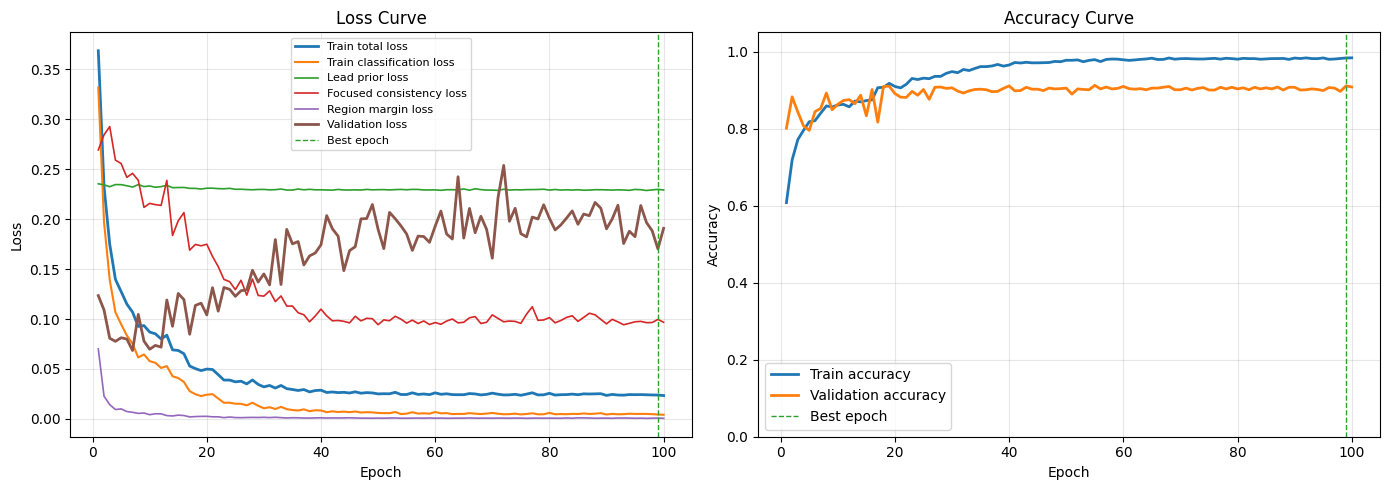

Training history saved to: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-classification/pretrain_model_localization/training_history.csv
Training curve saved to: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-classification/pretrain_model_localization/training_loss_accuracy_curve.png
Best epoch: 99 Best score: 0.787111152628986


In [45]:
def collect_outputs(model, loader, device):
    model.eval()
    losses, y_true, y_pred, y_prob = [], [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            prob = F.softmax(logits, dim=1)
            losses.append(loss.item() * xb.size(0))
            y_true.append(yb.detach().cpu().numpy())
            y_pred.append(prob.argmax(dim=1).detach().cpu().numpy())
            y_prob.append(prob.detach().cpu().numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.vstack(y_prob)
    return np.sum(losses) / len(y_true), y_true, y_pred, y_prob


def compute_summary_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    }


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    totals = {
        'loss': 0.0,
        'classification_loss': 0.0,
        'lead_prior_loss': 0.0,
        'focused_consistency_loss': 0.0,
        'region_margin_loss': 0.0,
    }
    total, correct = 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        xb_train = apply_lead_dropout(xb, yb)
        optimizer.zero_grad()
        logits, attn = model(xb_train, return_attention=True)
        cls_loss = criterion(logits, yb)
        prior_loss = lead_prior_regularization(attn['lead_attention'], yb)
        consistency_loss = focused_lead_consistency_loss(model, xb, yb, logits)
        margin_loss = region_margin_loss(model, xb, yb)
        loss = (
            cls_loss
            + CONFIG['lead_prior_lambda'] * prior_loss
            + CONFIG['focused_consistency_lambda'] * consistency_loss
            + CONFIG['region_margin_lambda'] * margin_loss
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['gradient_clip_norm'])
        optimizer.step()
        batch_n = xb.size(0)
        totals['loss'] += loss.item() * batch_n
        totals['classification_loss'] += cls_loss.item() * batch_n
        totals['lead_prior_loss'] += prior_loss.item() * batch_n
        totals['focused_consistency_loss'] += consistency_loss.item() * batch_n
        totals['region_margin_loss'] += margin_loss.item() * batch_n
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += batch_n
    return {k: v / max(total, 1) for k, v in totals.items()} | {'accuracy': correct / max(total, 1)}

best_score = -np.inf
best_epoch = 0
best_state = None
patience_counter = 0
history = []

for epoch in range(1, CONFIG['epochs'] + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, device)
    train_loss = train_metrics['loss']
    train_acc = train_metrics['accuracy']
    val_loss, yv_true, yv_pred, yv_prob = collect_outputs(model, val_loader, device)
    val_metrics = compute_summary_metrics(yv_true, yv_pred)
    score = val_metrics[CONFIG['selection_metric']]
    scheduler.step(score)

    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'train_classification_loss': train_metrics['classification_loss'],
        'train_lead_prior_loss': train_metrics['lead_prior_loss'],
        'train_focused_consistency_loss': train_metrics['focused_consistency_loss'],
        'train_region_margin_loss': train_metrics['region_margin_loss'],
        'train_accuracy': train_acc,
        'val_loss': val_loss,
        **{f'val_{k}': v for k, v in val_metrics.items()},
        'lr': optimizer.param_groups[0]['lr'],
    }
    history.append(row)

    if score > best_score:
        best_score = score
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        torch.save({
            'model_name': 'CNNLSTMSEAttentionLocalization',
            'state_dict': best_state,
            'class_names': class_names,
            'lead_names': lead_names,
            'region_leads': region_leads,
            'class_lead_prior': class_lead_prior,
            'lead_prior_weights': lead_prior_df.to_dict(),
            'lead_focus_mask': lead_focus_df.to_dict(),
            'config': CONFIG,
            'normalization': {
                'type': CONFIG['normalization'],
                'mean': normalizer.mean_,
                'std': normalizer.std_,
            },
            'best_epoch': best_epoch,
            'best_score': float(best_score),
            'split_warning': split_warning,
            'lmi_ready_generator': lmi_generator_metadata.to_dict(orient='records'),
        }, OUTPUT_DIR / 'best_model_localization_evidence.pth')
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch:03d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"cls={train_metrics['classification_loss']:.4f} prior={train_metrics['lead_prior_loss']:.4f} "
        f"focus_cons={train_metrics['focused_consistency_loss']:.4f} margin={train_metrics['region_margin_loss']:.4f} "
        f"val_loss={val_loss:.4f} val_acc={val_metrics['accuracy']:.4f} "
        f"val_macro_f1={val_metrics['macro_f1']:.4f} val_bal_acc={val_metrics['balanced_accuracy']:.4f} "
        f"best_{CONFIG['selection_metric']}={best_score:.4f}"
    )

    if CONFIG.get('use_early_stopping', False) and patience_counter >= CONFIG['patience']:
        print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train total loss', linewidth=2)
axes[0].plot(history_df['epoch'], history_df['train_classification_loss'], label='Train classification loss', linewidth=1.5)
axes[0].plot(history_df['epoch'], history_df['train_lead_prior_loss'], label='Lead prior loss', linewidth=1.2)
axes[0].plot(history_df['epoch'], history_df['train_focused_consistency_loss'], label='Focused consistency loss', linewidth=1.2)
axes[0].plot(history_df['epoch'], history_df['train_region_margin_loss'], label='Region margin loss', linewidth=1.2)
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='Validation loss', linewidth=2)
axes[0].axvline(best_epoch, color='tab:green', linestyle='--', linewidth=1, label='Best epoch')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(history_df['epoch'], history_df['train_accuracy'], label='Train accuracy', linewidth=2)
axes[1].plot(history_df['epoch'], history_df['val_accuracy'], label='Validation accuracy', linewidth=2)
axes[1].axvline(best_epoch, color='tab:green', linestyle='--', linewidth=1, label='Best epoch')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
curve_path = OUTPUT_DIR / 'training_loss_accuracy_curve.png'
fig.savefig(curve_path, dpi=200, bbox_inches='tight')
plt.show()

print('Training history saved to:', OUTPUT_DIR / 'training_history.csv')
print('Training curve saved to:', curve_path)
print('Best epoch:', best_epoch, 'Best score:', best_score)


## 12. Evaluation

In [46]:
def per_class_medical_metrics(y_true, y_pred, y_prob, class_names):
    labels = list(range(len(class_names)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    rows = []
    for i, name in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        binary = (y_true == i).astype(int)
        roc_auc = np.nan
        pr_auc = np.nan
        if len(np.unique(binary)) == 2:
            fpr, tpr, _ = roc_curve(binary, y_prob[:, i])
            roc_auc = auc(fpr, tpr)
            pr_auc = average_precision_score(binary, y_prob[:, i])
        rows.append({
            'class': name,
            'support': int((y_true == i).sum()),
            'sensitivity_recall': sensitivity,
            'specificity': specificity,
            'roc_auc_ovr': roc_auc,
            'pr_auc_ovr': pr_auc,
            'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn),
        })
    return pd.DataFrame(rows), cm


def mi_vs_norm_metrics(y_true, y_prob):
    y_bin = (y_true != label_to_idx['NORM']).astype(int)
    p_mi = 1.0 - y_prob[:, label_to_idx['NORM']]
    pred_bin = (np.argmax(y_prob, axis=1) != label_to_idx['NORM']).astype(int)
    cm = confusion_matrix(y_bin, pred_bin, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        'mi_vs_norm_sensitivity': tp / (tp + fn) if (tp + fn) else np.nan,
        'mi_vs_norm_specificity': tn / (tn + fp) if (tn + fp) else np.nan,
        'mi_vs_norm_roc_auc': auc(*roc_curve(y_bin, p_mi)[:2]) if len(np.unique(y_bin)) == 2 else np.nan,
        'mi_vs_norm_cm': cm,
    }


def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_boot=200, seed=42):
    rng = np.random.default_rng(seed)
    values = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        try:
            values.append(metric_fn(y_true[idx], y_pred[idx]))
        except Exception:
            pass
    if not values:
        return np.nan, np.nan
    return float(np.percentile(values, 2.5)), float(np.percentile(values, 97.5))


def evaluate_split(model, loader, split_name):
    loss, y_true, y_pred, y_prob = collect_outputs(model, loader, device)
    summary = compute_summary_metrics(y_true, y_pred)
    summary['loss'] = loss
    summary['split'] = split_name
    per_class_df, cm = per_class_medical_metrics(y_true, y_pred, y_prob, class_names)
    mi_norm = mi_vs_norm_metrics(y_true, y_prob)
    summary.update({k: v for k, v in mi_norm.items() if k != 'mi_vs_norm_cm'})
    summary['macro_f1_ci95'] = bootstrap_metric_ci(y_true, y_pred, lambda a, b: f1_score(a, b, average='macro', zero_division=0), CONFIG['bootstrap_iterations'])
    summary['balanced_accuracy_ci95'] = bootstrap_metric_ci(y_true, y_pred, balanced_accuracy_score, CONFIG['bootstrap_iterations'])
    return summary, per_class_df, cm, y_true, y_pred, y_prob

val_summary, val_per_class, val_cm, y_val_true, y_val_pred, y_val_prob = evaluate_split(model, val_loader, 'validation')
test_summary, test_per_class, test_cm, y_test_true, y_test_pred, y_test_prob = evaluate_split(model, test_loader, 'test')

summary_df = pd.DataFrame([val_summary, test_summary])
display(summary_df)
display(test_per_class)
print(classification_report(y_test_true, y_test_pred, target_names=class_names, zero_division=0))

summary_df.to_csv(OUTPUT_DIR / 'evaluation_summary.csv', index=False)
val_per_class.to_csv(OUTPUT_DIR / 'validation_per_class_metrics.csv', index=False)
test_per_class.to_csv(OUTPUT_DIR / 'test_per_class_metrics.csv', index=False)

,accuracy,macro_f1,weighted_f1,balanced_accuracy,loss,split,mi_vs_norm_sensitivity,mi_vs_norm_specificity,mi_vs_norm_roc_auc,macro_f1_ci95,balanced_accuracy_ci95
0,0.910905,0.787111,0.910302,0.751852,0.170294,validation,0.871245,0.948773,0.970903,"(0.6629087274891886, 0.8663821256712033)","(0.6591436895640861, 0.8462276175396398)"
1,0.897981,0.715834,0.895835,0.691907,0.249922,test,0.850990,0.942037,0.965727,"(0.6682995825282766, 0.7564077117439625)","(0.6582423489461581, 0.7252077494614471)"


,class,support,sensitivity_recall,specificity,roc_auc_ovr,pr_auc_ovr,tp,fp,tn,fn
0,NORM,1915,0.942037,0.850990,0.965727,0.982191,1804,128,731,111
1,IMI,443,0.812641,0.960532,0.971025,0.880235,360,92,2239,83
2,AMI,389,0.827763,0.974843,0.979232,0.907567,322,60,2325,67
3,LMI,27,0.185185,0.998908,0.925265,0.313789,5,3,2744,22


              precision    recall  f1-score   support

        NORM       0.93      0.94      0.94      1915
         IMI       0.80      0.81      0.80       443
         AMI       0.84      0.83      0.84       389
         LMI       0.62      0.19      0.29        27

    accuracy                           0.90      2774
   macro avg       0.80      0.69      0.72      2774
weighted avg       0.90      0.90      0.90      2774



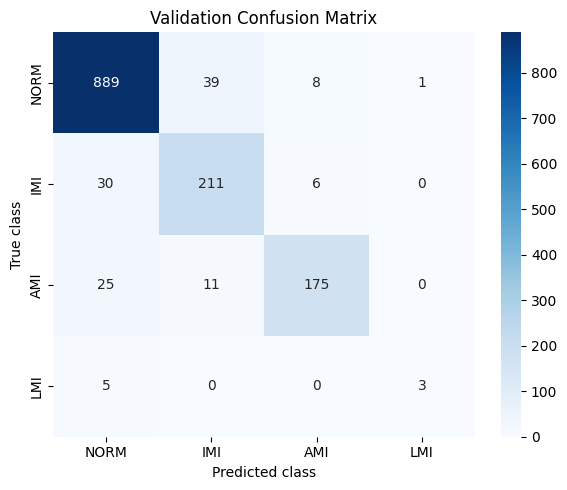

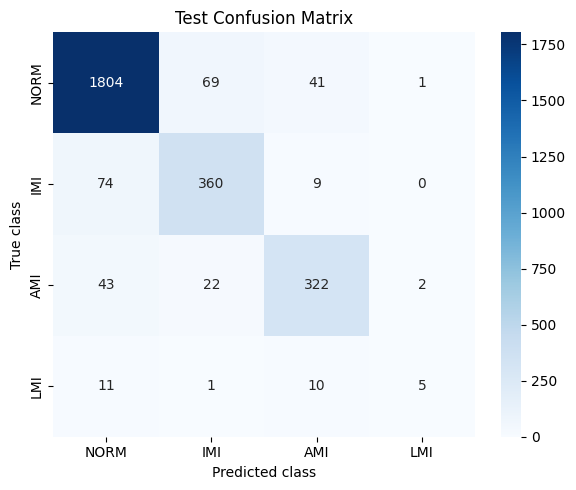

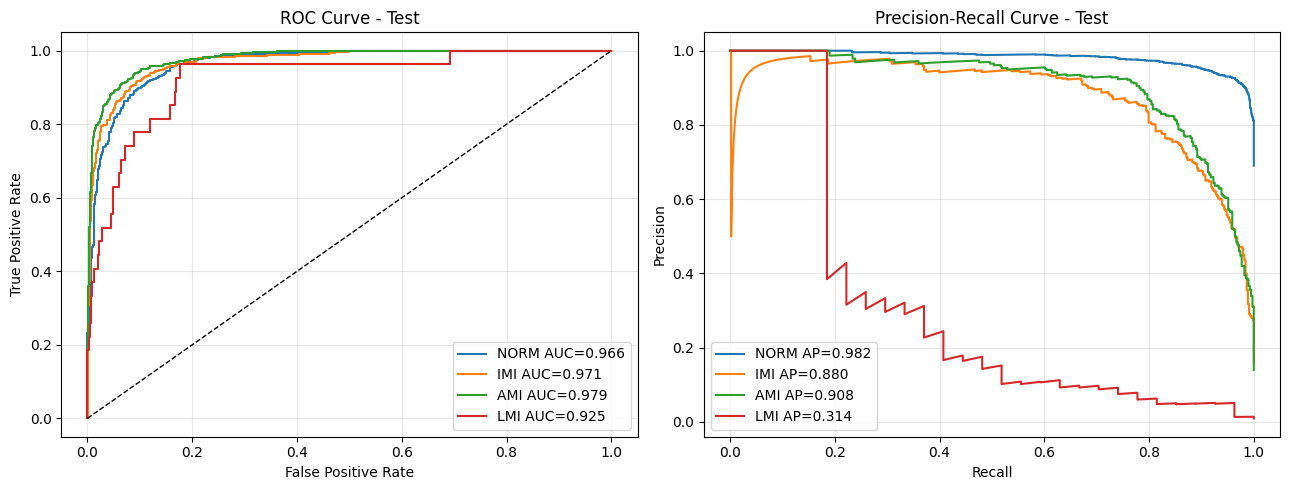

In [47]:
def plot_confusion(cm, title, out_path):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted class')
    plt.ylabel('True class')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()


def plot_roc_pr(y_true, y_prob, split_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for i, name in enumerate(class_names):
        binary = (y_true == i).astype(int)
        if len(np.unique(binary)) < 2:
            continue
        fpr, tpr, _ = roc_curve(binary, y_prob[:, i])
        precision, recall, _ = precision_recall_curve(binary, y_prob[:, i])
        axes[0].plot(fpr, tpr, label=f'{name} AUC={auc(fpr, tpr):.3f}')
        axes[1].plot(recall, precision, label=f'{name} AP={average_precision_score(binary, y_prob[:, i]):.3f}')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_title(f'ROC Curve - {split_name}')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[1].set_title(f'Precision-Recall Curve - {split_name}')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    for ax in axes:
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'roc_pr_{split_name.lower()}.png', dpi=300)
    plt.show()

plot_confusion(val_cm, 'Validation Confusion Matrix', OUTPUT_DIR / 'confusion_matrix_validation.png')
plot_confusion(test_cm, 'Test Confusion Matrix', OUTPUT_DIR / 'confusion_matrix_test.png')
plot_roc_pr(y_test_true, y_test_prob, 'Test')

## 13. Localization Analysis: Lead-wise dan Region Attention

In [48]:
def collect_attention(model, loader):
    model.eval()
    y_true, y_pred, probs, lead_attn, temporal_attn = [], [], [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits, attn = model(xb, return_attention=True)
            prob = F.softmax(logits, dim=1)
            y_true.append(yb.numpy())
            y_pred.append(prob.argmax(1).cpu().numpy())
            probs.append(prob.cpu().numpy())
            lead_attn.append(attn['lead_attention'].cpu().numpy())
            temporal_attn.append(attn['temporal_attention'].cpu().numpy())
    return {
        'y_true': np.concatenate(y_true),
        'y_pred': np.concatenate(y_pred),
        'prob': np.vstack(probs),
        'lead_attention': np.vstack(lead_attn),
        'temporal_attention': np.vstack(temporal_attn),
    }

attn_test = collect_attention(model, test_loader)
lead_attn_df = pd.DataFrame(attn_test['lead_attention'], columns=lead_names)
lead_attn_df['true_class'] = [class_names[i] for i in attn_test['y_true']]
lead_attn_df['pred_class'] = [class_names[i] for i in attn_test['y_pred']]

lead_by_true = lead_attn_df.groupby('true_class')[lead_names].mean().reindex(class_names)
lead_by_pred = lead_attn_df.groupby('pred_class')[lead_names].mean().reindex(class_names)

def region_scores_from_lead_attention(lead_attention):
    scores = {}
    for region, leads in region_leads.items():
        idx = [lead_to_idx[l] for l in leads]
        scores[region] = lead_attention[:, idx].sum(axis=1)
    return pd.DataFrame(scores)

region_df = region_scores_from_lead_attention(attn_test['lead_attention'])
region_df['true_class'] = lead_attn_df['true_class'].values
region_df['pred_class'] = lead_attn_df['pred_class'].values
region_by_true = region_df.groupby('true_class')[region_names].mean().reindex(index=class_names, columns=region_names)
region_by_pred = region_df.groupby('pred_class')[region_names].mean().reindex(index=class_names, columns=region_names)

display(lead_by_true)
display(region_by_true)
lead_by_true.to_csv(OUTPUT_DIR / 'lead_attention_by_true_class.csv')
region_by_true.to_csv(OUTPUT_DIR / 'region_attention_by_true_class.csv')
region_by_pred.to_csv(OUTPUT_DIR / 'region_attention_by_pred_class.csv')

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
true_class,,,,,,,,,,,,
NORM,0.083193,0.082236,0.085016,0.081998,0.084723,0.083690,0.084066,0.083565,0.083474,0.082685,0.082635,0.082720
IMI,0.081690,0.085660,0.082909,0.084003,0.080884,0.085293,0.082776,0.083316,0.082952,0.083040,0.083580,0.083898
AMI,0.085183,0.084722,0.079402,0.086959,0.081267,0.081239,0.082209,0.083118,0.082450,0.084372,0.084878,0.084201
LMI,0.087163,0.083850,0.081380,0.086972,0.083996,0.081174,0.083494,0.080672,0.079713,0.081955,0.085374,0.084259


,Inferior,Lateral,AnteriorSeptal
true_class,,,
NORM,0.250942,0.333271,0.333789
IMI,0.253861,0.330051,0.332085
AMI,0.245363,0.335529,0.332149
LMI,0.246404,0.340791,0.325833


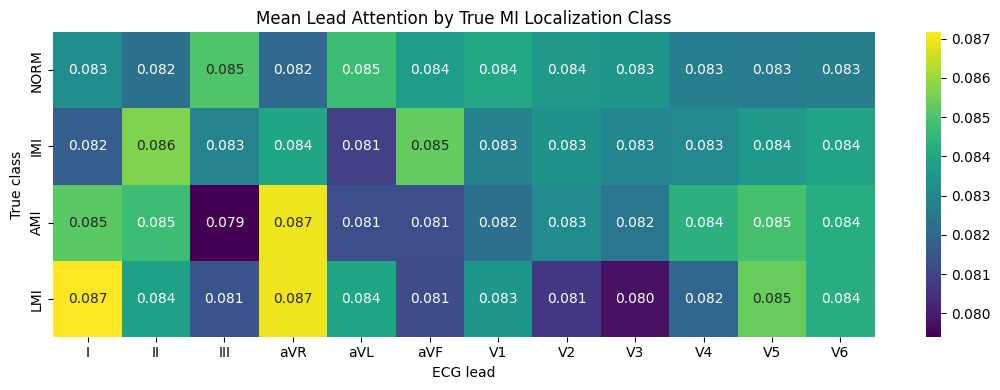

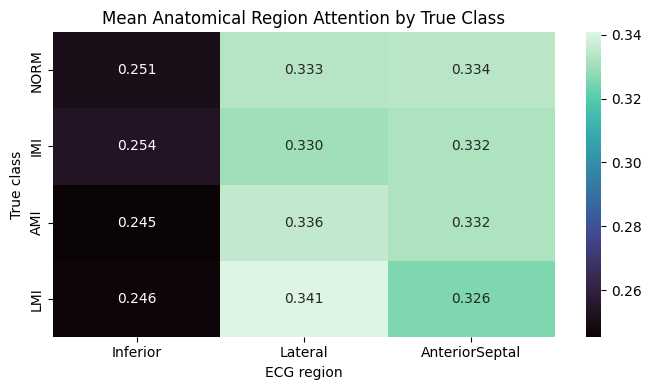

In [49]:
def plot_attention_tables():
    plt.figure(figsize=(11, 4))
    sns.heatmap(lead_by_true, annot=True, fmt='.3f', cmap='viridis')
    plt.title('Mean Lead Attention by True MI Localization Class')
    plt.xlabel('ECG lead')
    plt.ylabel('True class')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'lead_attention_by_true_class.png', dpi=300)
    plt.show()

    plt.figure(figsize=(7, 4))
    sns.heatmap(region_by_true, annot=True, fmt='.3f', cmap='mako')
    plt.title('Mean Anatomical Region Attention by True Class')
    plt.xlabel('ECG region')
    plt.ylabel('True class')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'region_attention_by_true_class.png', dpi=300)
    plt.show()

plot_attention_tables()

## 14. Interpretability Visualization dan Occlusion Test

In [50]:
def predict_prob(model, x_batch):
    model.eval()
    if len(x_batch) == 0:
        return np.empty((0, len(class_names)), dtype=np.float32)
    with torch.no_grad():
        logits = model(torch.tensor(x_batch, dtype=torch.float32, device=device))
        return F.softmax(logits, dim=1).cpu().numpy()


def occlusion_fill_values(x_samples):
    if CONFIG.get('occlusion_baseline', 'train_lead_mean') == 'zero':
        return np.zeros((1, 1, x_samples.shape[2]), dtype=np.float32)
    return x_train_n.mean(axis=(0, 1), keepdims=True).astype(np.float32)


def occlude_leads(x, lead_indices, fill_values=None):
    x_occ = x.copy()
    if fill_values is None:
        fill_values = occlusion_fill_values(x)
    x_occ[:, :, lead_indices] = fill_values[:, :, lead_indices]
    return x_occ


def lead_occlusion_importance(model, x_samples, target_classes, source_indices=None):
    if source_indices is None:
        source_indices = np.arange(len(x_samples))
    base_prob = predict_prob(model, x_samples)
    fill_values = occlusion_fill_values(x_samples)
    rows = []
    for lead_idx, lead in enumerate(lead_names):
        occ_prob = predict_prob(model, occlude_leads(x_samples, [lead_idx], fill_values))
        for i, target in enumerate(target_classes):
            rows.append({
                'source_index': int(source_indices[i]),
                'target_class_id': int(target),
                'target_class': class_names[int(target)],
                'lead': lead,
                'importance_drop': float(base_prob[i, int(target)] - occ_prob[i, int(target)]),
                'base_probability': float(base_prob[i, int(target)]),
                'occluded_probability': float(occ_prob[i, int(target)]),
                'occlusion_baseline': CONFIG.get('occlusion_baseline', 'train_lead_mean'),
            })
    return pd.DataFrame(rows)


def region_occlusion_importance(model, x_samples, target_classes, source_indices=None):
    if source_indices is None:
        source_indices = np.arange(len(x_samples))
    base_prob = predict_prob(model, x_samples)
    fill_values = occlusion_fill_values(x_samples)
    rows = []
    for region, leads in region_leads.items():
        lead_indices = [lead_to_idx[l] for l in leads]
        occ_prob = predict_prob(model, occlude_leads(x_samples, lead_indices, fill_values))
        for i, target in enumerate(target_classes):
            rows.append({
                'source_index': int(source_indices[i]),
                'target_class_id': int(target),
                'target_class': class_names[int(target)],
                'region': region,
                'importance_drop': float(base_prob[i, int(target)] - occ_prob[i, int(target)]),
                'base_probability': float(base_prob[i, int(target)]),
                'occluded_probability': float(occ_prob[i, int(target)]),
                'occlusion_baseline': CONFIG.get('occlusion_baseline', 'train_lead_mean'),
            })
    return pd.DataFrame(rows)


def focused_vs_nonfocused_score(model, x_samples, target_classes, source_indices=None):
    if source_indices is None:
        source_indices = np.arange(len(x_samples))
    rows = []
    for i, target in enumerate(target_classes):
        target = int(target)
        if target == label_to_idx['NORM']:
            continue
        focus_idx = class_focus_indices(target)
        nonfocus_idx = class_nonfocus_indices(target)
        if not focus_idx or not nonfocus_idx:
            continue
        sample = x_samples[i:i + 1]
        full_prob = predict_prob(model, sample)[0, target]
        focus_prob = predict_prob(model, mask_to_leads(torch.tensor(sample, dtype=torch.float32), focus_idx).numpy())[0, target]
        nonfocus_prob = predict_prob(model, mask_to_leads(torch.tensor(sample, dtype=torch.float32), nonfocus_idx).numpy())[0, target]
        rows.append({
            'source_index': int(source_indices[i]),
            'target_class_id': target,
            'target_class': class_names[target],
            'focused_probability': float(focus_prob),
            'nonfocused_probability': float(nonfocus_prob),
            'full_probability': float(full_prob),
            'focused_minus_nonfocused': float(focus_prob - nonfocus_prob),
            'passes_negative_test': bool(focus_prob > nonfocus_prob),
        })
    return pd.DataFrame(rows)


def select_balanced_occlusion_samples(x, y_true, max_per_class=64):
    selected = []
    for class_idx, class_name in enumerate(class_names):
        idx = np.where(y_true == class_idx)[0]
        if len(idx) == 0:
            warnings.warn(f'No true samples for {class_name}; occlusion heatmap row will remain unavailable.', RuntimeWarning)
            continue
        selected.extend(idx[:max_per_class].tolist())
    selected = np.array(selected, dtype=int)
    return x[selected], y_true[selected], selected

x_occ_samples, y_occ_targets, occ_source_indices = select_balanced_occlusion_samples(
    x_test_n,
    y_test_true,
    max_per_class=64,
)

lead_occ_df = lead_occlusion_importance(model, x_occ_samples, y_occ_targets, occ_source_indices)
region_occ_df = region_occlusion_importance(model, x_occ_samples, y_occ_targets, occ_source_indices)
negative_test_df = focused_vs_nonfocused_score(model, x_occ_samples, y_occ_targets, occ_source_indices)
lead_occ_summary = (
    lead_occ_df.groupby(['target_class', 'lead'], sort=False)['importance_drop']
    .mean()
    .unstack()
    .reindex(index=class_names, columns=lead_names)
)
region_occ_summary = (
    region_occ_df.groupby(['target_class', 'region'], sort=False)['importance_drop']
    .mean()
    .unstack()
    .reindex(index=class_names, columns=region_names)
)
negative_test_summary = (
    negative_test_df.groupby('target_class')['focused_minus_nonfocused']
    .agg(['mean', 'median', 'count'])
    .reindex(index=['IMI', 'AMI', 'LMI'])
)

correct_mask = y_test_true == y_test_pred
x_test_correct = x_test_n[correct_mask]
y_test_correct = y_test_true[correct_mask]
correct_source_indices = np.where(correct_mask)[0]
if len(x_test_correct) > 0:
    lead_occ_correct_df = lead_occlusion_importance(model, x_test_correct, y_test_correct, correct_source_indices)
    region_occ_correct_df = region_occlusion_importance(model, x_test_correct, y_test_correct, correct_source_indices)
    lead_occ_correct_summary = (
        lead_occ_correct_df.groupby(['target_class', 'lead'], sort=False)['importance_drop']
        .mean()
        .unstack()
        .reindex(index=class_names, columns=lead_names)
    )
    region_occ_correct_summary = (
        region_occ_correct_df.groupby(['target_class', 'region'], sort=False)['importance_drop']
        .mean()
        .unstack()
        .reindex(index=class_names, columns=region_names)
    )
else:
    lead_occ_correct_df = pd.DataFrame()
    region_occ_correct_df = pd.DataFrame()
    lead_occ_correct_summary = pd.DataFrame(index=class_names, columns=lead_names)
    region_occ_correct_summary = pd.DataFrame(index=class_names, columns=region_names)

lead_occ_df.to_csv(OUTPUT_DIR / 'lead_occlusion_sample_level.csv', index=False)
region_occ_df.to_csv(OUTPUT_DIR / 'region_occlusion_sample_level.csv', index=False)
lead_occ_summary.to_csv(OUTPUT_DIR / 'lead_occlusion_mean_by_true_class.csv')
region_occ_summary.to_csv(OUTPUT_DIR / 'region_occlusion_mean_by_true_class.csv')
negative_test_df.to_csv(OUTPUT_DIR / 'focused_vs_nonfocused_negative_test.csv', index=False)
negative_test_summary.to_csv(OUTPUT_DIR / 'focused_vs_nonfocused_negative_test_summary.csv')
lead_occ_correct_df.to_csv(OUTPUT_DIR / 'lead_occlusion_correct_only_sample_level.csv', index=False)
region_occ_correct_df.to_csv(OUTPUT_DIR / 'region_occlusion_correct_only_sample_level.csv', index=False)
lead_occ_correct_summary.to_csv(OUTPUT_DIR / 'lead_occlusion_correct_only_mean_by_class.csv')
region_occ_correct_summary.to_csv(OUTPUT_DIR / 'region_occlusion_correct_only_mean_by_class.csv')

print('Occlusion sample counts by true class:')
print(pd.Series([class_names[i] for i in y_occ_targets]).value_counts().reindex(class_names, fill_value=0))
print('\nCorrect-only occlusion sample counts by class:')
if len(y_test_correct) > 0:
    print(pd.Series([class_names[i] for i in y_test_correct]).value_counts().reindex(class_names, fill_value=0))
else:
    print('No correctly classified samples.')

print('\nFocused-vs-nonfocused negative test summary:')
display(negative_test_summary)
display(region_occ_summary)


Occlusion sample counts by true class:
NORM    64
IMI     64
AMI     64
LMI     27
Name: count, dtype: int64

Correct-only occlusion sample counts by class:
NORM    1804
IMI      360
AMI      322
LMI        5
Name: count, dtype: int64

Focused-vs-nonfocused negative test summary:


,mean,median,count
target_class,,,
IMI,0.703318,0.929098,64
AMI,0.577336,0.788931,64
LMI,0.891426,0.992560,27


region,Inferior,Lateral,AnteriorSeptal
target_class,,,
NORM,-0.033608,0.305763,0.128595
IMI,0.465696,-0.122472,-0.042409
AMI,-0.152259,-0.092186,0.348437
LMI,-0.109890,0.154833,-0.347520


In [51]:
def localization_sanity_check(region_attention_by_true, region_occlusion_by_class, negative_summary=None):
    rows = []
    for cls, expected_region in expected_region_by_class.items():
        attn_best = None
        occ_best = None
        attn_ok = False
        occ_ok = False
        negative_margin = np.nan
        negative_ok = False
        if cls in region_attention_by_true.index:
            vals = region_attention_by_true.loc[cls].dropna()
            if len(vals):
                attn_best = vals.idxmax()
                attn_ok = attn_best == expected_region
        if cls in region_occlusion_by_class.index:
            vals = region_occlusion_by_class.loc[cls].dropna()
            if len(vals):
                occ_best = vals.idxmax()
                occ_ok = occ_best == expected_region
        if negative_summary is not None and cls in negative_summary.index and pd.notna(negative_summary.loc[cls, 'mean']):
            negative_margin = float(negative_summary.loc[cls, 'mean'])
            negative_ok = negative_margin > 0
        rows.append({
            'class': cls,
            'expected_region': expected_region,
            'attention_top_region': attn_best,
            'attention_matches_expected': attn_ok,
            'occlusion_top_region': occ_best,
            'occlusion_matches_expected': occ_ok,
            'focused_minus_nonfocused_mean': negative_margin,
            'negative_test_passes': negative_ok,
            'localization_evidence_status': 'supports limited localization' if attn_ok and occ_ok and negative_ok else 'weak or inconsistent localization evidence',
        })
    return pd.DataFrame(rows)

sanity_df = localization_sanity_check(region_by_true, region_occ_summary, negative_test_summary)
display(sanity_df)
sanity_df.to_csv(OUTPUT_DIR / 'localization_sanity_check.csv', index=False)

if not sanity_df['localization_evidence_status'].eq('supports limited localization').all():
    warnings.warn('Localization evidence is weak/inconsistent for at least one MI class. Do not claim clinical localization.', RuntimeWarning)


,class,expected_region,attention_top_region,attention_matches_expected,occlusion_top_region,occlusion_matches_expected,focused_minus_nonfocused_mean,negative_test_passes,localization_evidence_status
0,IMI,Inferior,AnteriorSeptal,False,Inferior,True,0.703318,True,weak or inconsistent localization evidence
1,LMI,Lateral,Lateral,True,Lateral,True,0.891426,True,supports limited localization
2,AMI,AnteriorSeptal,Lateral,False,AnteriorSeptal,True,0.577336,True,weak or inconsistent localization evidence


/tmp/ipykernel_91809/3004057033.py:41: RuntimeWarning: Localization evidence is weak/inconsistent for at least one MI class. Do not claim clinical localization.
  warnings.warn('Localization evidence is weak/inconsistent for at least one MI class. Do not claim clinical localization.', RuntimeWarning)


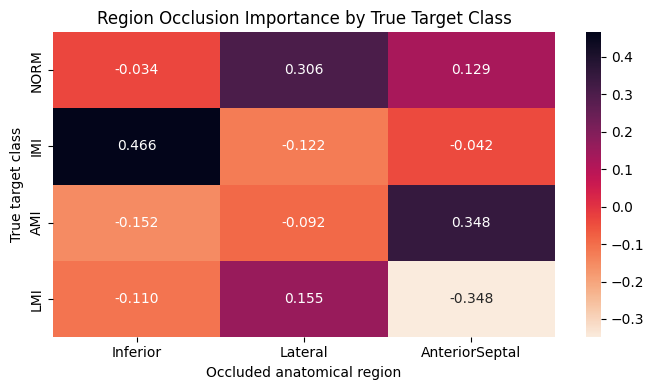

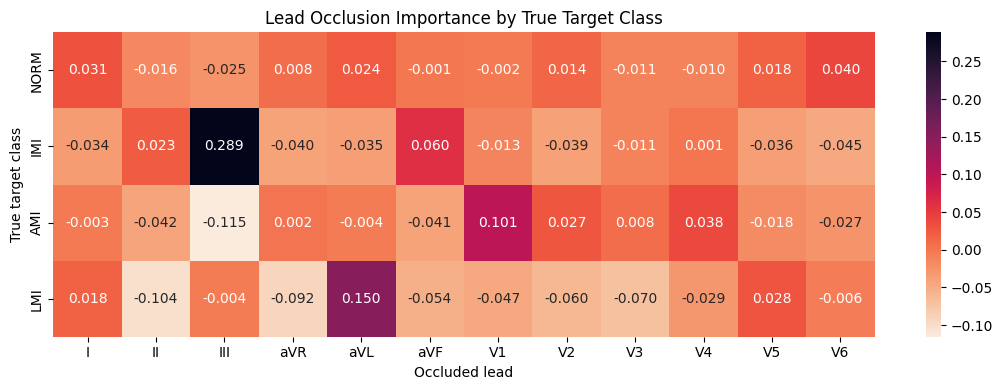

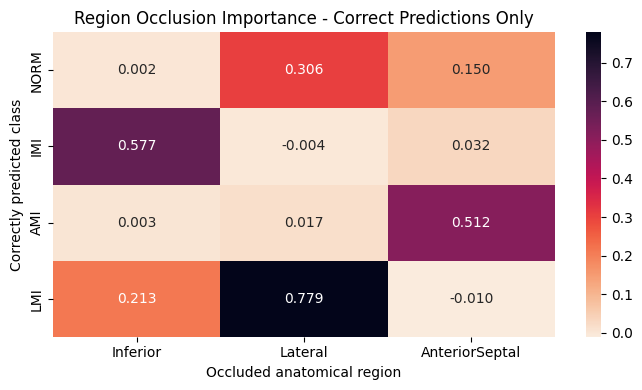

In [52]:
def plot_occlusion_results():
    plt.figure(figsize=(7, 4))
    sns.heatmap(region_occ_summary, annot=True, fmt='.3f', cmap='rocket_r', mask=region_occ_summary.isna())
    plt.title('Region Occlusion Importance by True Target Class')
    plt.xlabel('Occluded anatomical region')
    plt.ylabel('True target class')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'region_occlusion_importance_by_true_class.png', dpi=300)
    plt.show()

    plt.figure(figsize=(11, 4))
    sns.heatmap(lead_occ_summary, annot=True, fmt='.3f', cmap='rocket_r', mask=lead_occ_summary.isna())
    plt.title('Lead Occlusion Importance by True Target Class')
    plt.xlabel('Occluded lead')
    plt.ylabel('True target class')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'lead_occlusion_importance_by_true_class.png', dpi=300)
    plt.show()

    # Optional stricter plot. LMI may be blank here if the model never correctly predicts LMI.
    plt.figure(figsize=(7, 4))
    sns.heatmap(region_occ_correct_summary, annot=True, fmt='.3f', cmap='rocket_r', mask=region_occ_correct_summary.isna())
    plt.title('Region Occlusion Importance - Correct Predictions Only')
    plt.xlabel('Occluded anatomical region')
    plt.ylabel('Correctly predicted class')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'region_occlusion_importance_correct_only.png', dpi=300)
    plt.show()

plot_occlusion_results()


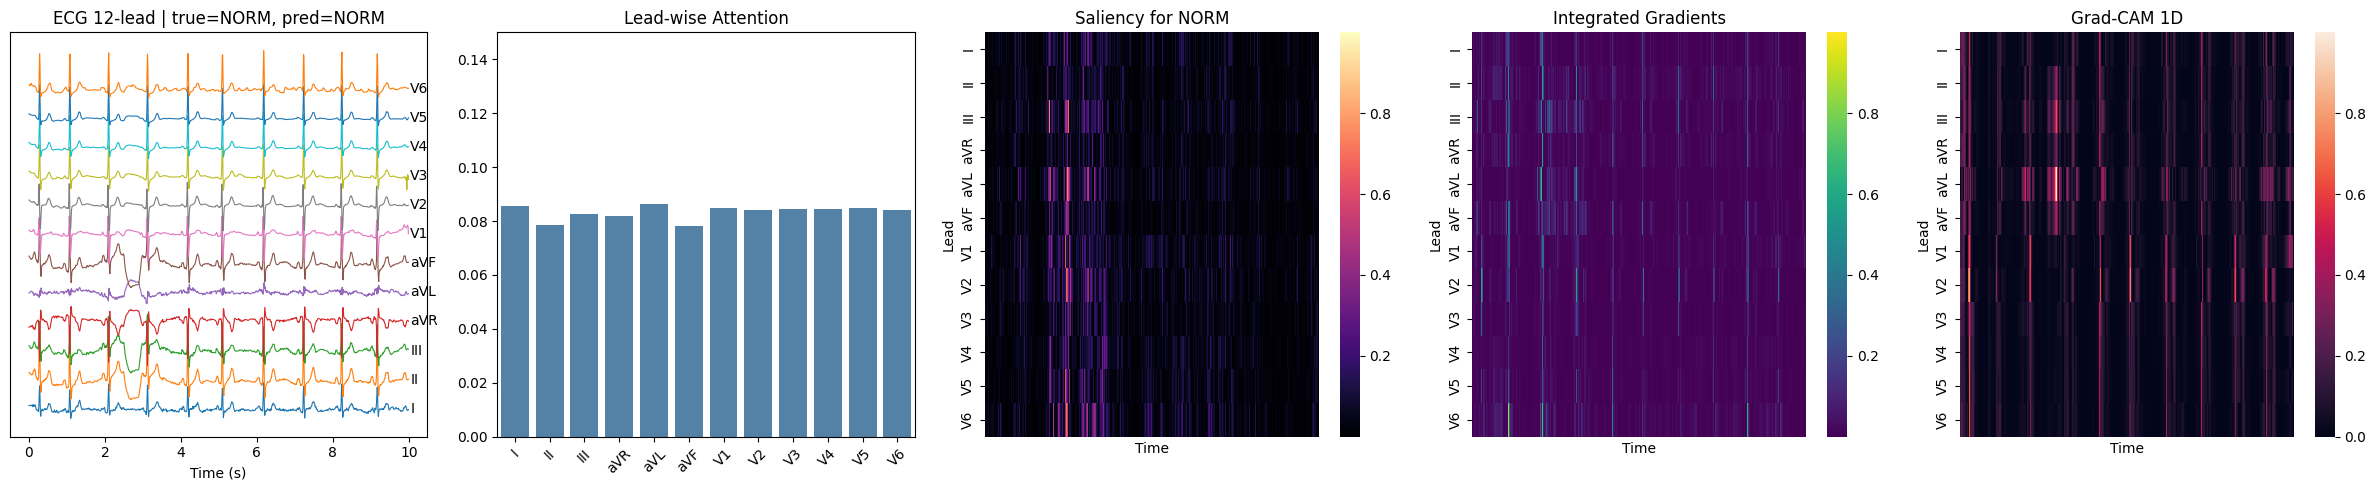

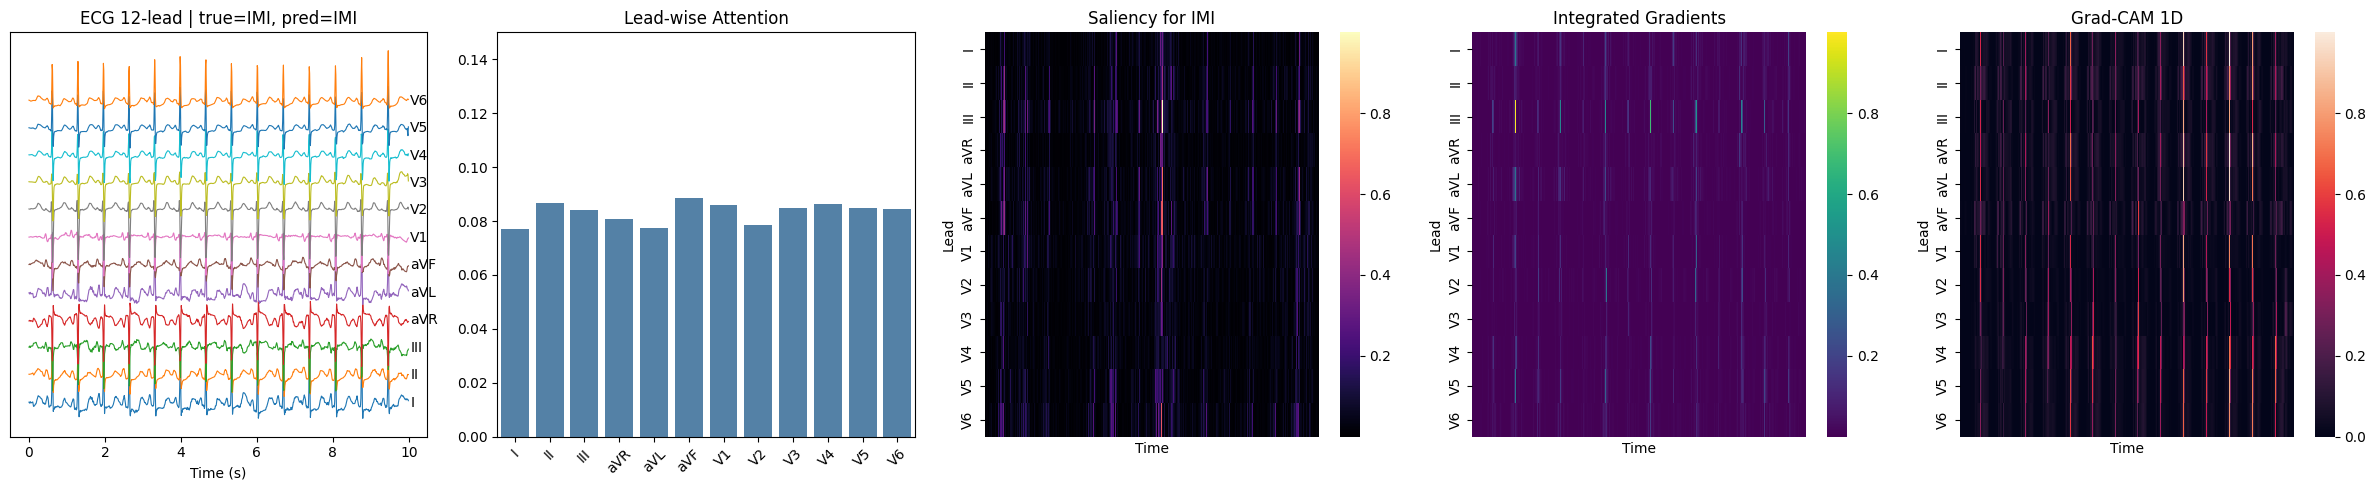

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
class,,,,,,,,,,,,
NORM,0.018518,0.020967,0.016392,0.019223,0.014870,0.018005,0.021435,0.024387,0.017217,0.016988,0.016391,0.021427
IMI,0.009360,0.008672,0.020539,0.007319,0.012662,0.011419,0.012440,0.012516,0.010428,0.011098,0.009044,0.010379
AMI,0.010898,0.011525,0.016136,0.009496,0.015452,0.012432,0.015214,0.012427,0.012444,0.014179,0.011256,0.012449
LMI,0.008802,0.012070,0.017959,0.008522,0.018033,0.014516,0.017149,0.017270,0.015536,0.014263,0.012165,0.013478


,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
class,,,,,,,,,,,,
NORM,0.071161,0.057861,0.050798,0.061073,0.061360,0.053962,0.038498,0.048832,0.071789,0.055311,0.053000,0.051487
IMI,0.041127,0.052288,0.045477,0.053902,0.038021,0.051120,0.039556,0.045549,0.045160,0.040816,0.034688,0.040587
AMI,0.032150,0.038952,0.032845,0.036039,0.032205,0.035775,0.031094,0.043488,0.043245,0.034476,0.030722,0.028739
LMI,0.019425,0.020485,0.016609,0.019866,0.017749,0.017950,0.015978,0.018002,0.019143,0.018418,0.016547,0.016983


In [53]:
def saliency_map(model, x_sample, target_class=None):
    was_training = model.training
    model.eval()
    x = torch.tensor(x_sample[None], dtype=torch.float32, device=device)
    x.requires_grad_(True)
    model.zero_grad(set_to_none=True)

    with torch.backends.cudnn.flags(enabled=False):
        logits = model(x)
        if target_class is None:
            target_class = int(logits.argmax(1).item())
        else:
            target_class = int(target_class)
        score = logits[0, target_class]
        score.backward()

    sal = x.grad.detach().abs().cpu().numpy()[0]
    sal = sal / (sal.max() + 1e-8)
    if was_training:
        model.train()
    return sal, target_class


def integrated_gradients(model, x_sample, target_class=None, steps=None, baseline=None):
    was_training = model.training
    model.eval()
    steps = int(steps or CONFIG.get('integrated_gradients_steps', 24))
    x = torch.tensor(x_sample[None], dtype=torch.float32, device=device)
    if baseline is None:
        baseline_np = np.broadcast_to(x_train_n.mean(axis=(0, 1), keepdims=True), x_sample[None].shape).astype(np.float32)
    else:
        baseline_np = baseline.astype(np.float32)
    baseline_t = torch.tensor(baseline_np, dtype=torch.float32, device=device)
    if target_class is None:
        with torch.no_grad():
            target_class = int(model(x).argmax(1).item())
    grads = []
    with torch.backends.cudnn.flags(enabled=False):
        for alpha in torch.linspace(0.0, 1.0, steps, device=device):
            interpolated = baseline_t + alpha * (x - baseline_t)
            interpolated.requires_grad_(True)
            model.zero_grad(set_to_none=True)
            score = model(interpolated)[0, int(target_class)]
            grad = torch.autograd.grad(score, interpolated, retain_graph=False)[0]
            grads.append(grad.detach())
    avg_grad = torch.stack(grads).mean(dim=0)
    ig = ((x - baseline_t) * avg_grad).detach().abs().cpu().numpy()[0]
    ig = ig / (ig.max() + 1e-8)
    if was_training:
        model.train()
    return ig, int(target_class)


def gradcam_1d(model, x_sample, target_class=None):
    was_training = model.training
    model.eval()
    activations = []
    gradients = []

    def fwd_hook(module, inp, out):
        activations.append(out)

    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    handle_fwd = model.conv4.register_forward_hook(fwd_hook)
    handle_bwd = model.conv4.register_full_backward_hook(bwd_hook)
    x = torch.tensor(x_sample[None], dtype=torch.float32, device=device)
    model.zero_grad(set_to_none=True)
    with torch.backends.cudnn.flags(enabled=False):
        logits = model(x)
        if target_class is None:
            target_class = int(logits.argmax(1).item())
        score = logits[0, int(target_class)]
        score.backward()
    handle_fwd.remove()
    handle_bwd.remove()
    act = activations[0].detach()
    grad = gradients[0].detach()
    weights = grad.mean(dim=2, keepdim=True)
    cam = F.relu((weights * act).sum(dim=1)).cpu().numpy()[0]
    cam = np.interp(np.linspace(0, len(cam) - 1, x_sample.shape[0]), np.arange(len(cam)), cam)
    cam = cam / (cam.max() + 1e-8)
    lead_energy = np.abs(x_sample)
    lead_energy = lead_energy / (lead_energy.max(axis=0, keepdims=True) + 1e-8)
    lead_time_cam = lead_energy * cam[:, None]
    lead_time_cam = lead_time_cam / (lead_time_cam.max() + 1e-8)
    if was_training:
        model.train()
    return lead_time_cam, int(target_class)


def aggregate_interpretability_by_class(model, x, y_true, max_per_class=16):
    rows = []
    for class_idx, class_name in enumerate(class_names):
        idx = np.where(y_true == class_idx)[0][:max_per_class]
        for source_idx in idx:
            ig, _ = integrated_gradients(model, x[source_idx], target_class=class_idx)
            cam, _ = gradcam_1d(model, x[source_idx], target_class=class_idx)
            rows.append({
                'source_index': int(source_idx),
                'class': class_name,
                **{f'ig_{lead}': float(ig[:, lead_i].mean()) for lead_i, lead in enumerate(lead_names)},
                **{f'gradcam_{lead}': float(cam[:, lead_i].mean()) for lead_i, lead in enumerate(lead_names)},
            })
    df = pd.DataFrame(rows)
    if df.empty:
        return df, pd.DataFrame(index=class_names, columns=lead_names), pd.DataFrame(index=class_names, columns=lead_names)
    ig_summary = df.groupby('class')[[f'ig_{lead}' for lead in lead_names]].mean()
    ig_summary.columns = lead_names
    cam_summary = df.groupby('class')[[f'gradcam_{lead}' for lead in lead_names]].mean()
    cam_summary.columns = lead_names
    return df, ig_summary.reindex(class_names), cam_summary.reindex(class_names)


interpretability_df, integrated_gradients_by_class, gradcam_by_class = aggregate_interpretability_by_class(
    model,
    x_test_n,
    y_test_true,
    max_per_class=CONFIG.get('gradcam_max_samples_per_class', 16),
)
interpretability_df.to_csv(OUTPUT_DIR / 'integrated_gradients_gradcam_sample_level.csv', index=False)
integrated_gradients_by_class.to_csv(OUTPUT_DIR / 'integrated_gradients_mean_by_true_class.csv')
gradcam_by_class.to_csv(OUTPUT_DIR / 'gradcam_1d_mean_by_true_class.csv')

def plot_ecg_with_interpretability(sample_idx=0):
    x_sample = x_test_n[sample_idx]
    y_true_name = class_names[y_test_true[sample_idx]]
    y_pred_name = class_names[y_test_pred[sample_idx]]
    sal, target = saliency_map(model, x_sample, y_test_pred[sample_idx])
    ig, _ = integrated_gradients(model, x_sample, target)
    cam, _ = gradcam_1d(model, x_sample, target)

    with torch.no_grad():
        logits, attn = model(torch.tensor(x_sample[None], dtype=torch.float32, device=device), return_attention=True)
        lead_att = attn['lead_attention'].cpu().numpy()[0]

    n_time = x_sample.shape[0]
    t = np.arange(n_time) / CONFIG['sampling_frequency_hz']

    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    offset = 0
    for i, lead in enumerate(lead_names):
        signal = x_sample[:, i]
        axes[0].plot(t, signal + offset, lw=0.8)
        axes[0].text(t[-1] + 0.05, offset, lead, va='center')
        offset += 4
    axes[0].set_title(f'ECG 12-lead | true={y_true_name}, pred={y_pred_name}')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_yticks([])

    sns.barplot(x=lead_names, y=lead_att, ax=axes[1], color='steelblue')
    axes[1].set_title('Lead-wise Attention')
    axes[1].set_ylim(0, max(lead_att.max() * 1.2, 0.15))
    axes[1].tick_params(axis='x', rotation=45)

    sns.heatmap(sal.T, cmap='magma', ax=axes[2], yticklabels=lead_names, xticklabels=False)
    axes[2].set_title(f'Saliency for {class_names[target]}')
    axes[2].set_ylabel('Lead')
    axes[2].set_xlabel('Time')

    sns.heatmap(ig.T, cmap='viridis', ax=axes[3], yticklabels=lead_names, xticklabels=False)
    axes[3].set_title('Integrated Gradients')
    axes[3].set_ylabel('Lead')
    axes[3].set_xlabel('Time')

    sns.heatmap(cam.T, cmap='rocket', ax=axes[4], yticklabels=lead_names, xticklabels=False)
    axes[4].set_title('Grad-CAM 1D')
    axes[4].set_ylabel('Lead')
    axes[4].set_xlabel('Time')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'interpretability_sample_{sample_idx}.png', dpi=300)
    plt.show()

plot_ecg_with_interpretability(0)
mi_correct_indices = np.where((y_test_true != label_to_idx['NORM']) & (y_test_true == y_test_pred))[0]
if len(mi_correct_indices):
    plot_ecg_with_interpretability(int(mi_correct_indices[0]))

display(integrated_gradients_by_class)
display(gradcam_by_class)


## 15. Final Summary dan Conclusion

In [54]:
final_verdict = 'layak untuk klasifikasi saja'
if split_warning is None and sanity_df['localization_evidence_status'].eq('supports limited localization').all():
    final_verdict = 'layak untuk klasifikasi + lokalisasi terbatas'
elif split_warning is not None or not sanity_df['localization_evidence_status'].eq('supports limited localization').all():
    final_verdict = 'belum layak untuk lokalisasi'

final_summary = {
    'classification_task': 'NORM/IMI/AMI/LMI multiclass classification',
    'localization_claim': 'MI localization class with localization evidence; not clinical localization',
    'final_verdict': final_verdict,
    'split_warning': split_warning,
    'best_epoch': best_epoch,
    'best_selection_metric': CONFIG['selection_metric'],
    'best_score': float(best_score),
    'test_macro_f1': float(test_summary['macro_f1']),
    'test_weighted_f1': float(test_summary['weighted_f1']),
    'test_balanced_accuracy': float(test_summary['balanced_accuracy']),
    'test_mi_vs_norm_sensitivity': float(test_summary['mi_vs_norm_sensitivity']),
    'test_mi_vs_norm_specificity': float(test_summary['mi_vs_norm_specificity']),
    'lead_prior_enabled': bool(CONFIG.get('use_lead_prior_regularization', False)),
    'lead_dropout_enabled': bool(CONFIG.get('use_lead_dropout', False)),
    'focused_consistency_enabled': bool(CONFIG.get('use_focused_lead_consistency', False)),
    'region_margin_enabled': bool(CONFIG.get('use_region_margin_loss', False)),
    'occlusion_baseline': CONFIG.get('occlusion_baseline', 'train_lead_mean'),
}

with open(OUTPUT_DIR / 'final_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=2)

with pd.ExcelWriter(OUTPUT_DIR / 'final_report.xlsx', engine='openpyxl') as writer:
    pd.DataFrame([final_summary]).to_excel(writer, sheet_name='Final_Summary', index=False)
    history_df.to_excel(writer, sheet_name='Training_History', index=False)
    lmi_generator_metadata.to_excel(writer, sheet_name='LMI_Generator', index=False)
    summary_df.to_excel(writer, sheet_name='Evaluation_Summary', index=False)
    test_per_class.to_excel(writer, sheet_name='Test_Per_Class', index=False)
    lead_prior_df.to_excel(writer, sheet_name='Lead_Prior')
    lead_focus_df.to_excel(writer, sheet_name='Lead_Focus_Mask')
    lead_by_true.to_excel(writer, sheet_name='Lead_Attn_True_Class')
    region_by_true.to_excel(writer, sheet_name='Region_Attn_True_Class')
    lead_occ_summary.to_excel(writer, sheet_name='Lead_Occlusion')
    region_occ_summary.to_excel(writer, sheet_name='Region_Occlusion')
    lead_occ_correct_summary.to_excel(writer, sheet_name='Lead_Occ_Correct')
    region_occ_correct_summary.to_excel(writer, sheet_name='Region_Occ_Correct')
    negative_test_summary.to_excel(writer, sheet_name='Focused_Negative_Test')
    integrated_gradients_by_class.to_excel(writer, sheet_name='Integrated_Gradients')
    gradcam_by_class.to_excel(writer, sheet_name='GradCAM_1D')
    sanity_df.to_excel(writer, sheet_name='Localization_Sanity', index=False)

print(json.dumps(final_summary, indent=2))
print('Saved final report to:', OUTPUT_DIR / 'final_report.xlsx')


{
  "classification_task": "NORM/IMI/AMI/LMI multiclass classification",
  "localization_claim": "MI localization class with localization evidence; not clinical localization",
  "final_verdict": "belum layak untuk lokalisasi",
  "split_warning": null,
  "best_epoch": 99,
  "best_selection_metric": "macro_f1",
  "best_score": 0.787111152628986,
  "test_macro_f1": 0.7158340214688875,
  "test_weighted_f1": 0.8958347958945166,
  "test_balanced_accuracy": 0.6919065795938482,
  "test_mi_vs_norm_sensitivity": 0.8509895227008148,
  "test_mi_vs_norm_specificity": 0.9420365535248042,
  "lead_prior_enabled": true,
  "lead_dropout_enabled": true,
  "focused_consistency_enabled": true,
  "region_margin_enabled": true,
  "occlusion_baseline": "train_lead_mean"
}
Saved final report to: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-classification/pretrain_model_localization/final_report.xlsx


## H. Cara Menjalankan Notebook Dari Awal

1. Pastikan `DATA_DIR` menunjuk ke folder dataset berisi `x_train.npy`, `y_train.npy`, `x_val.npy`, `y_val.npy`, `x_test.npy`, `y_test.npy`.
2. Untuk klaim ilmiah kuat, tambahkan `x_all.npy`, `y_all.npy`, dan `patient_ids_all.npy` agar split patient-level bisa dibuat otomatis.
3. Jalankan semua cell dari atas ke bawah.
4. Artefak output tersimpan di `pretrain_model_localization_reviewed/`.
5. Gunakan `best_model_localization_evidence.pth` untuk downstream fine-tuning.

## I. Final Verdict

Notebook ini dirancang untuk menghasilkan salah satu verdict berikut secara otomatis:
- `layak untuk klasifikasi saja`
- `layak untuk klasifikasi + lokalisasi terbatas`
- `belum layak untuk lokalisasi`

Jika patient-level split tidak tersedia atau attention/occlusion tidak sesuai anatomi lead, jangan klaim clinical localization.